In [11]:
# ==============================================================================
# UPDATED CELL 1: SETUP AND COMPLETE CATEGORICAL ORDER MAPPING
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Step 1: Loading Dataset ---")
df = pd.read_csv("Cleaned_Topic3_healthcare_analytics_dataset.csv")
print(f"Dataset securely loaded. Total observations: {df.shape[0]} rows.")

print("\n--- Step 2: Fixing Categorical Axis Ordering for ALL Text Metrics ---")

# Defining explicit logical structures for ALL text/categorical metrics in the dataset [Certain]
stay_order = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100', 'More than 100 Days']
age_order = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100']
severity_order = ['Minor', 'Moderate', 'Extreme']
admission_order = ['Emergency', 'Urgent', 'Trauma']
hospital_type_order = sorted(df['Hospital_type_code'].unique()) # Sorts a, b, c, d, etc. alphabetically
region_order = sorted(df['Hospital_region_code'].unique())       # Sorts X, Y, Z alphabetically
dept_order = sorted(df['Department'].unique())                   # Sorts gynecology, anesthesia, etc.
ward_order = sorted(df['Ward_Type'].unique())                    # Sorts R, S, Q, etc.
facility_order = sorted(df['Ward_Facility_Code'].unique())        # Sorts A, B, C, etc.

# Safely reconfigure EVERY text column into an ordered categorical block [Certain]
df['Stay'] = pd.Categorical(df['Stay'], categories=stay_order, ordered=True)
df['Age'] = pd.Categorical(df['Age'], categories=age_order, ordered=True)
df['Severity of Illness'] = pd.Categorical(df['Severity of Illness'], categories=severity_order, ordered=True)
df['Type of Admission'] = pd.Categorical(df['Type of Admission'], categories=admission_order, ordered=True)
df['Hospital_type_code'] = pd.Categorical(df['Hospital_type_code'], categories=hospital_type_order, ordered=True)
df['Hospital_region_code'] = pd.Categorical(df['Hospital_region_code'], categories=region_order, ordered=True)
df['Department'] = pd.Categorical(df['Department'], categories=dept_order, ordered=True)
df['Ward_Type'] = pd.Categorical(df['Ward_Type'], categories=ward_order, ordered=True)
df['Ward_Facility_Code'] = pd.Categorical(df['Ward_Facility_Code'], categories=facility_order, ordered=True)

print("All missing metric configurations resolved. Re-run your universal controller cell now.")

--- Step 1: Loading Dataset ---
Dataset securely loaded. Total observations: 313793 rows.

--- Step 2: Fixing Categorical Axis Ordering for ALL Text Metrics ---
All missing metric configurations resolved. Re-run your universal controller cell now.


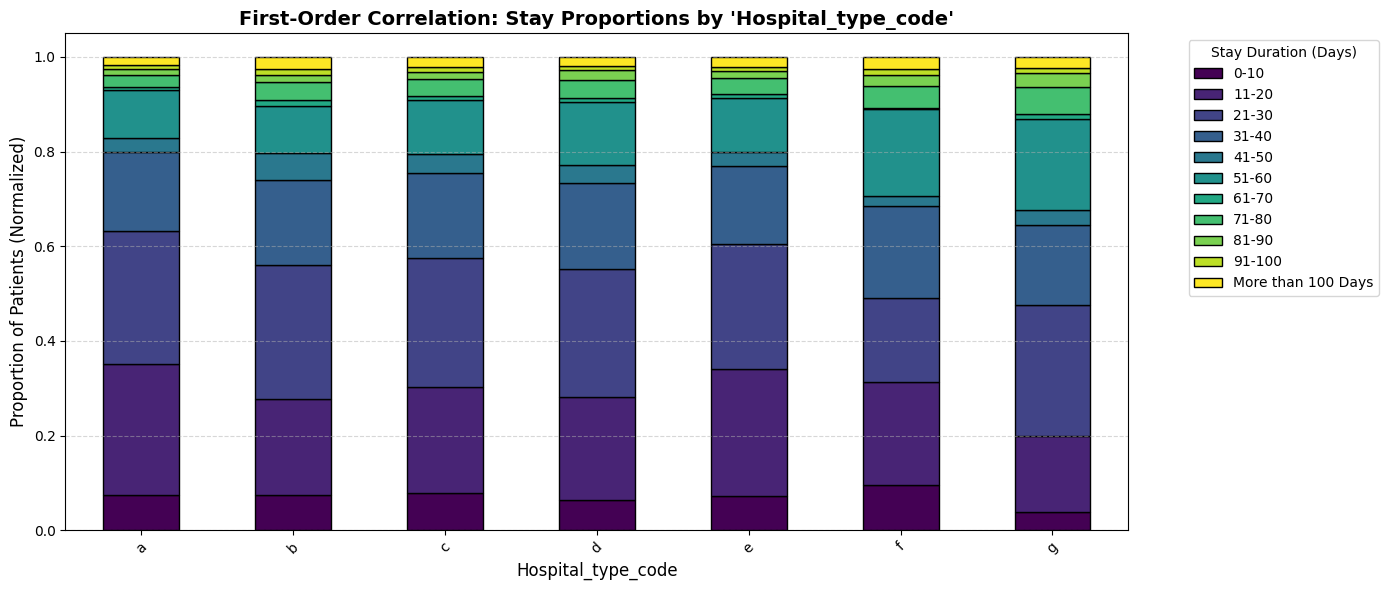

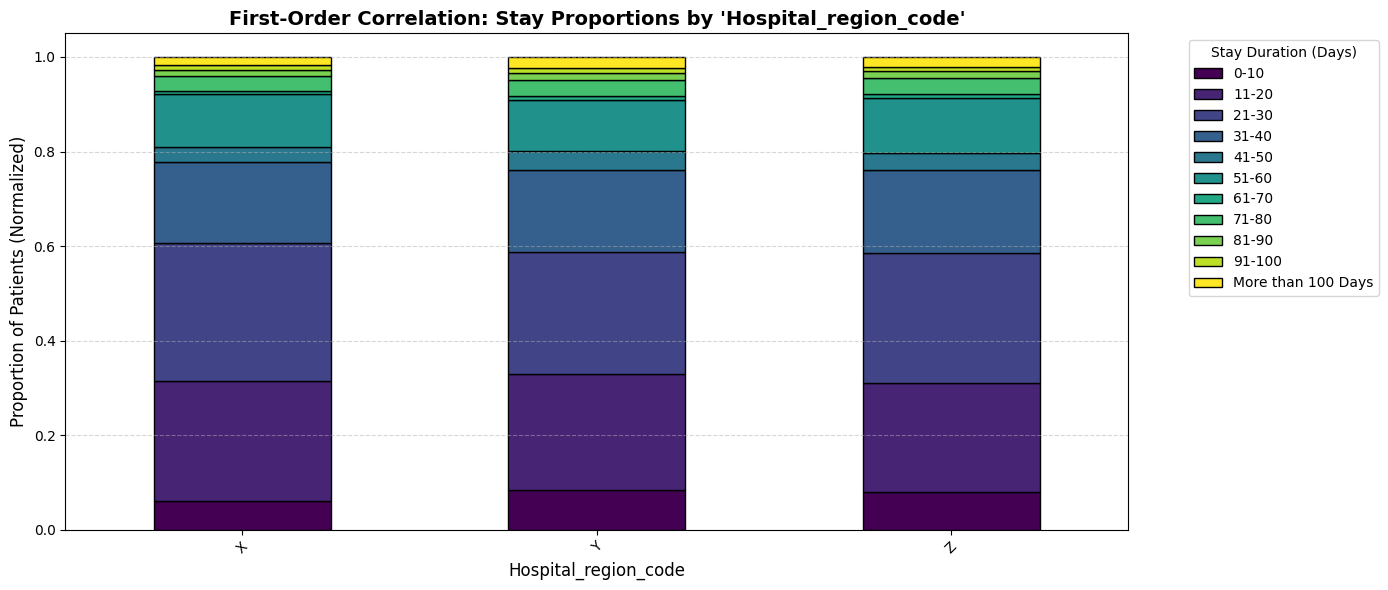

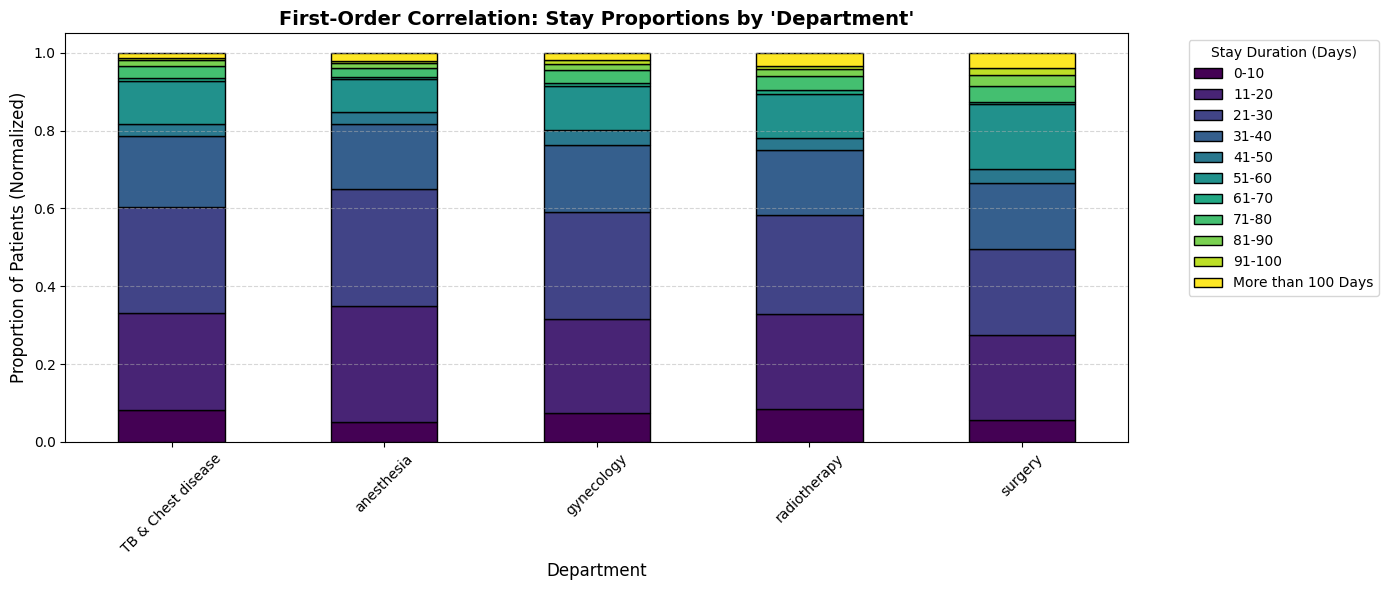

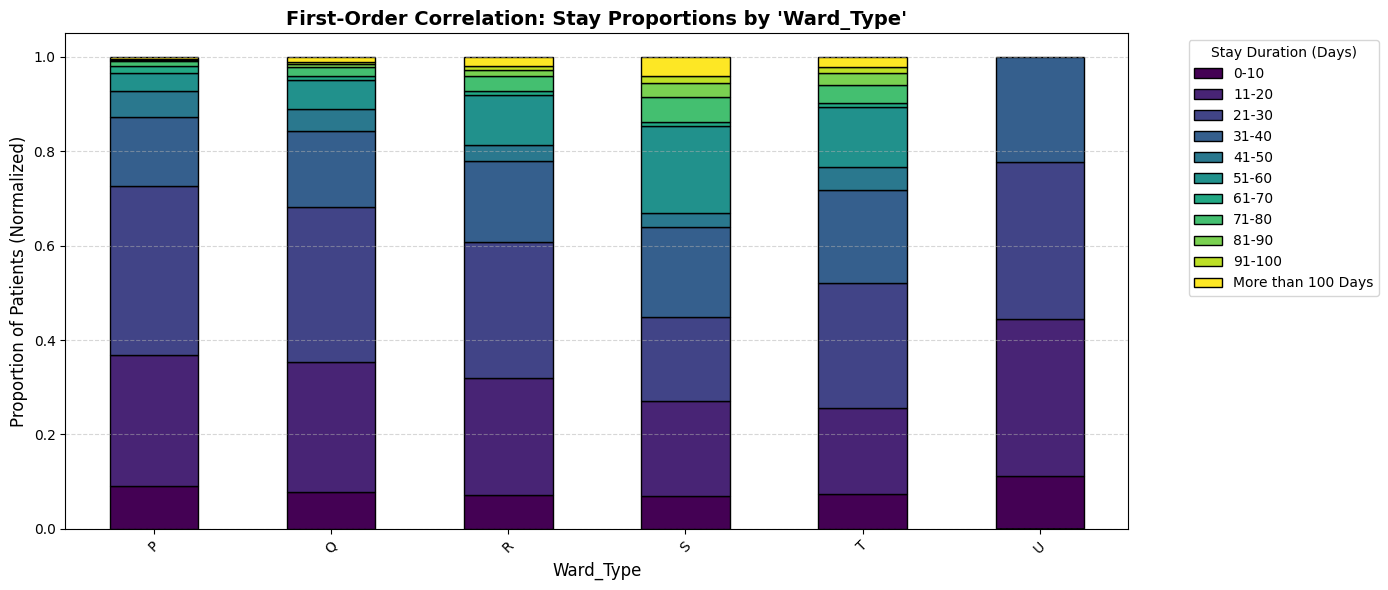

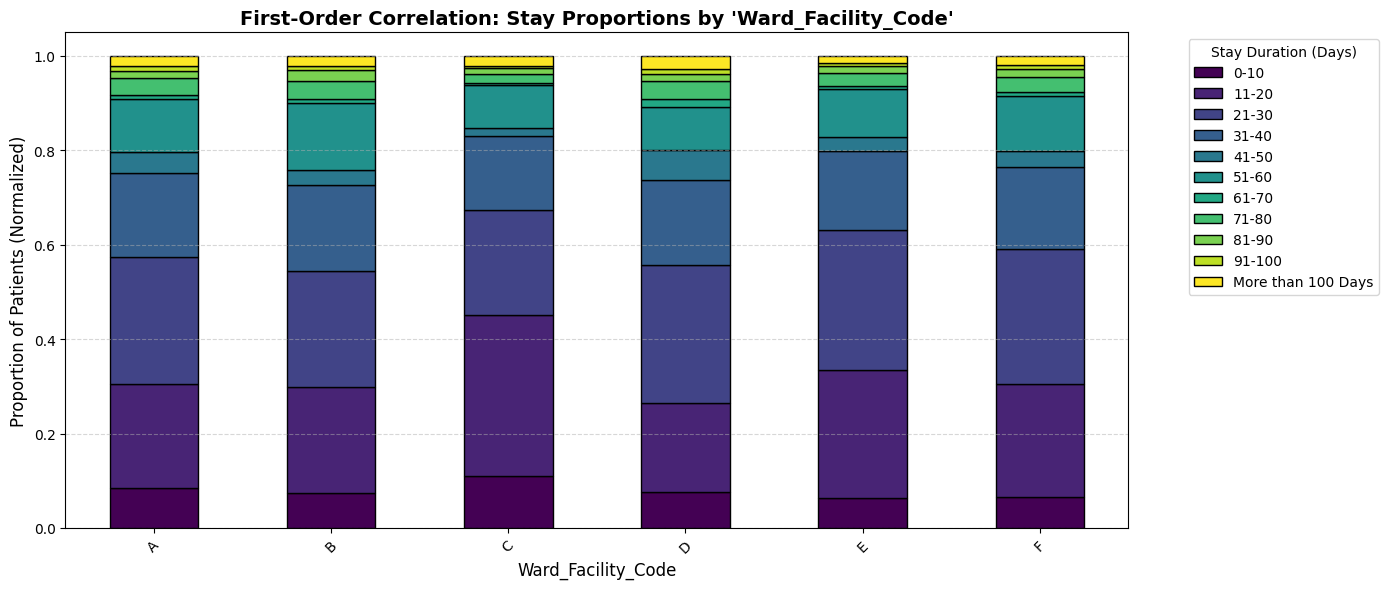

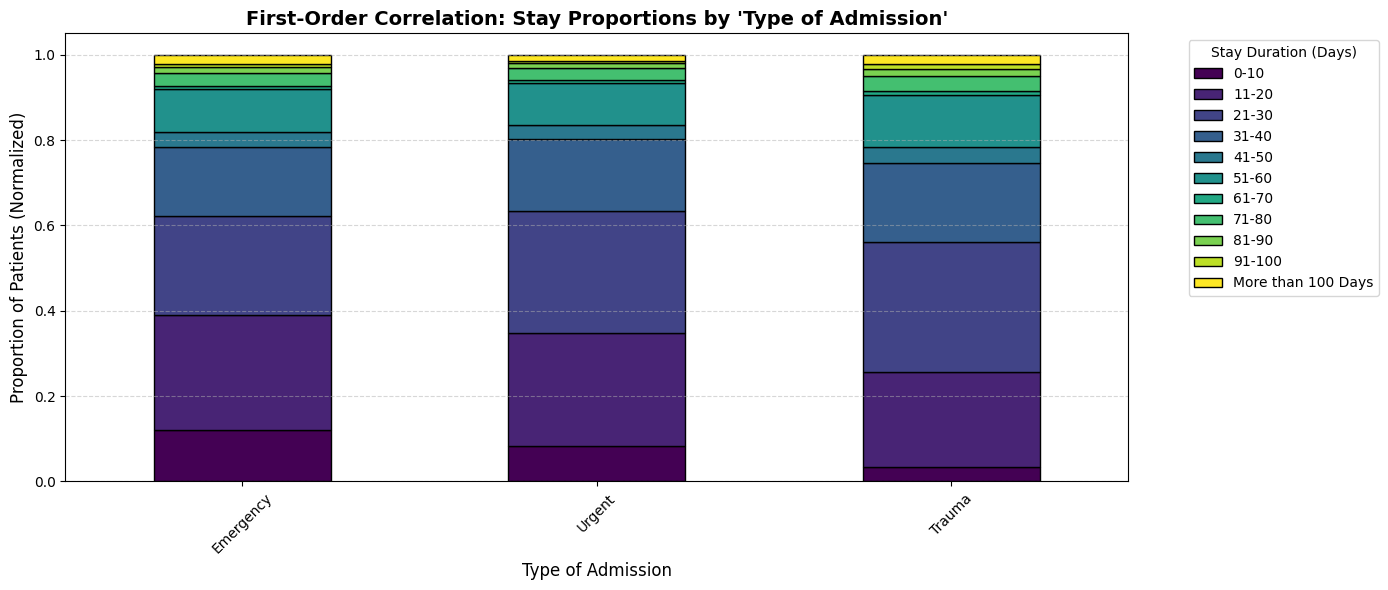

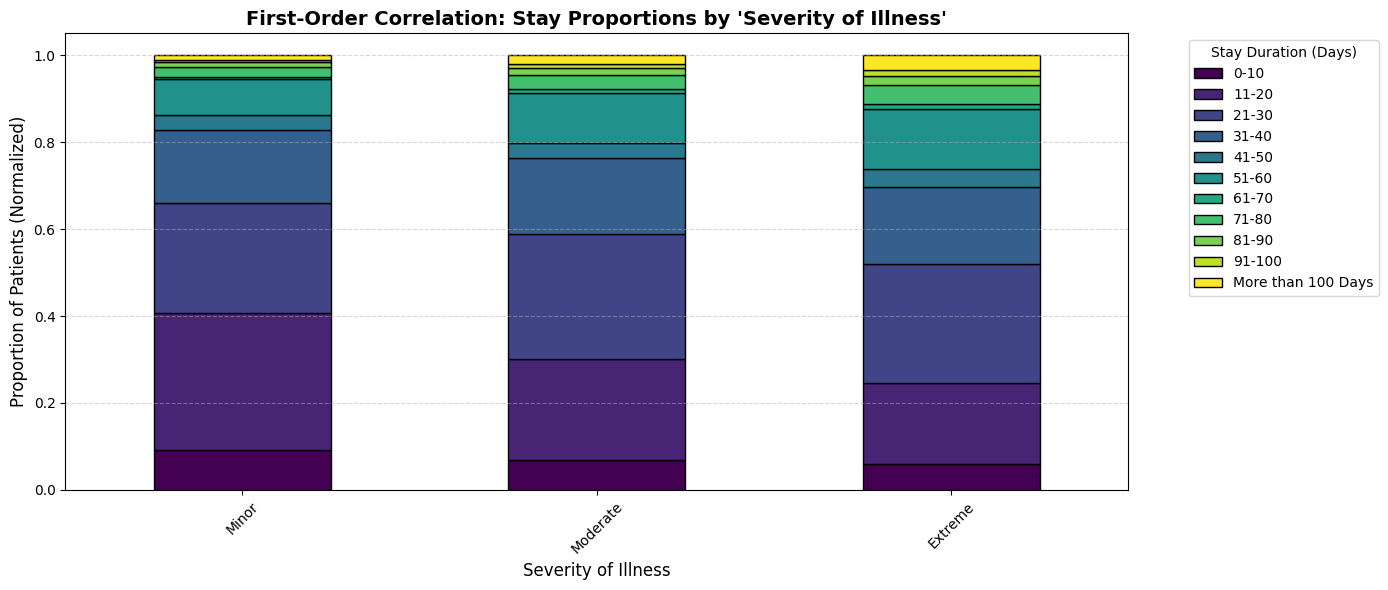

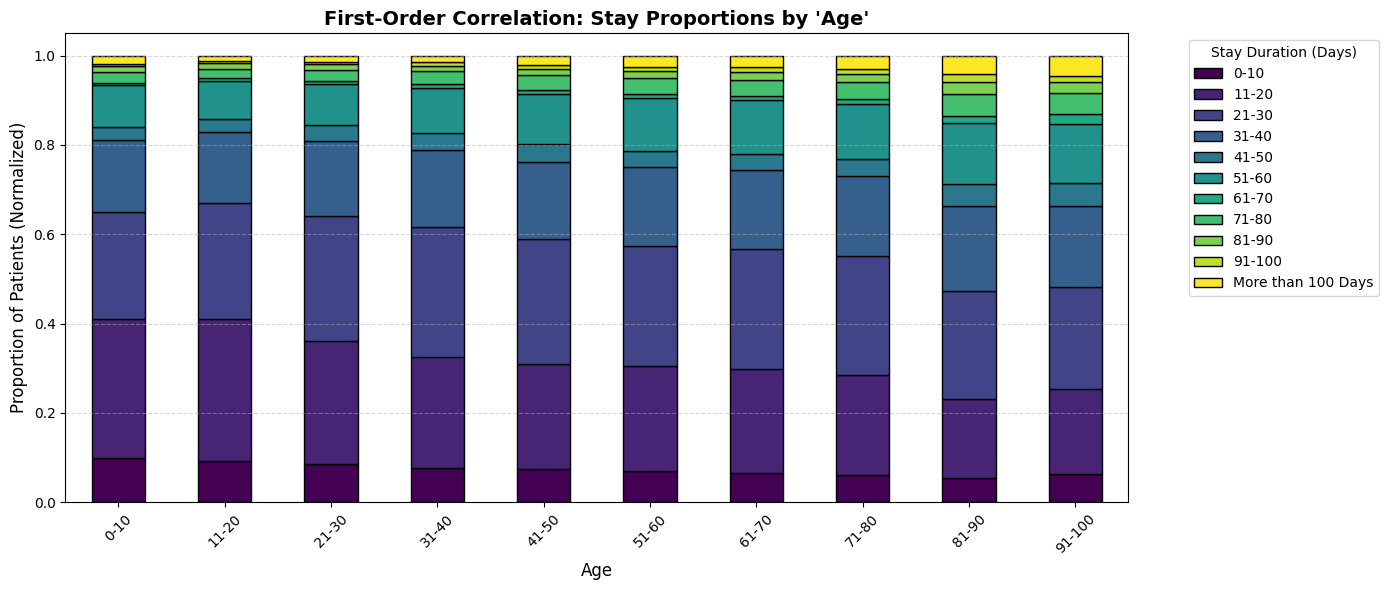

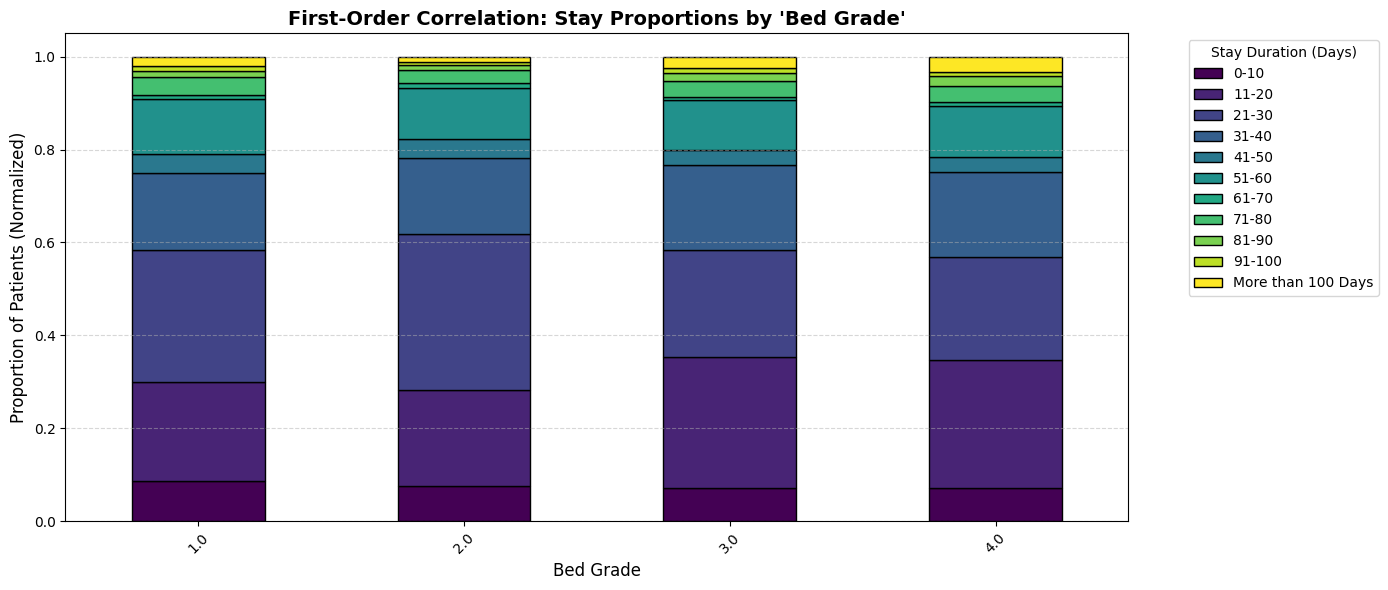

In [12]:
# ==============================================================================
# CELL 2: AUTOMATED FIRST-ORDER CORRELATION LOOPS
# ==============================================================================
def plot_first_order_correlation(dataframe, column_name):
    """
    Generates a normalized stacked bar plot to evaluate how a single variable
    correlates with shifts in patient Stay distributions.
    """
    # Cross-tabulate and normalize to 100% (1.0) to eliminate volume bias [Certain]
    crosstab = pd.crosstab(dataframe[column_name], dataframe['Stay'])
    crosstab_normalized = crosstab.div(crosstab.sum(1), axis=0)

    plt.figure(figsize=(14, 6))
    crosstab_normalized.plot(kind='bar', stacked=True, colormap='viridis', edgecolor='black', ax=plt.gca())

    plt.title(f"First-Order Correlation: Stay Proportions by '{column_name}'", fontsize=14, fontweight='bold')
    plt.xlabel(column_name, fontsize=12)
    plt.ylabel("Proportion of Patients (Normalized)", fontsize=12)
    plt.legend(title="Stay Duration (Days)", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# List of target metrics to cycle through completely automatically
first_order_columns = [
    'Hospital_type_code', 'Hospital_region_code', 'Department',
    'Ward_Type', 'Ward_Facility_Code', 'Type of Admission',
    'Severity of Illness', 'Age', 'Bed Grade'
]

# Run the automation loop across all defined metrics
for col in first_order_columns:
    plot_first_order_correlation(df, col)

/tmp/ipykernel_27901/2362927074.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack()


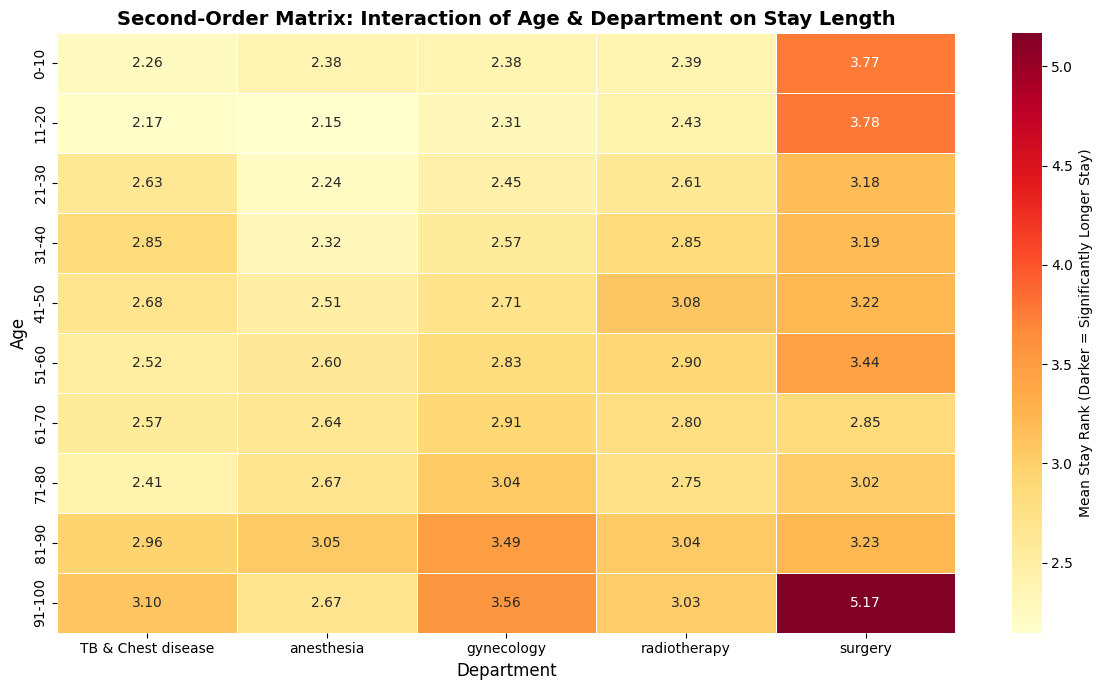

/tmp/ipykernel_27901/2362927074.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack()


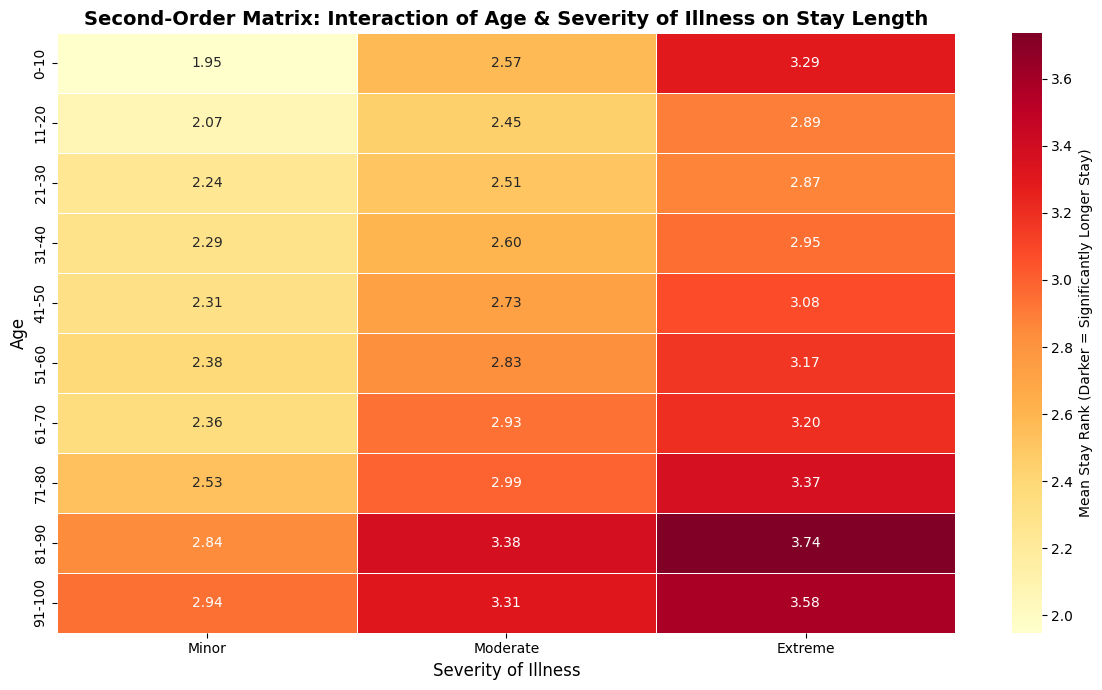

/tmp/ipykernel_27901/2362927074.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack()


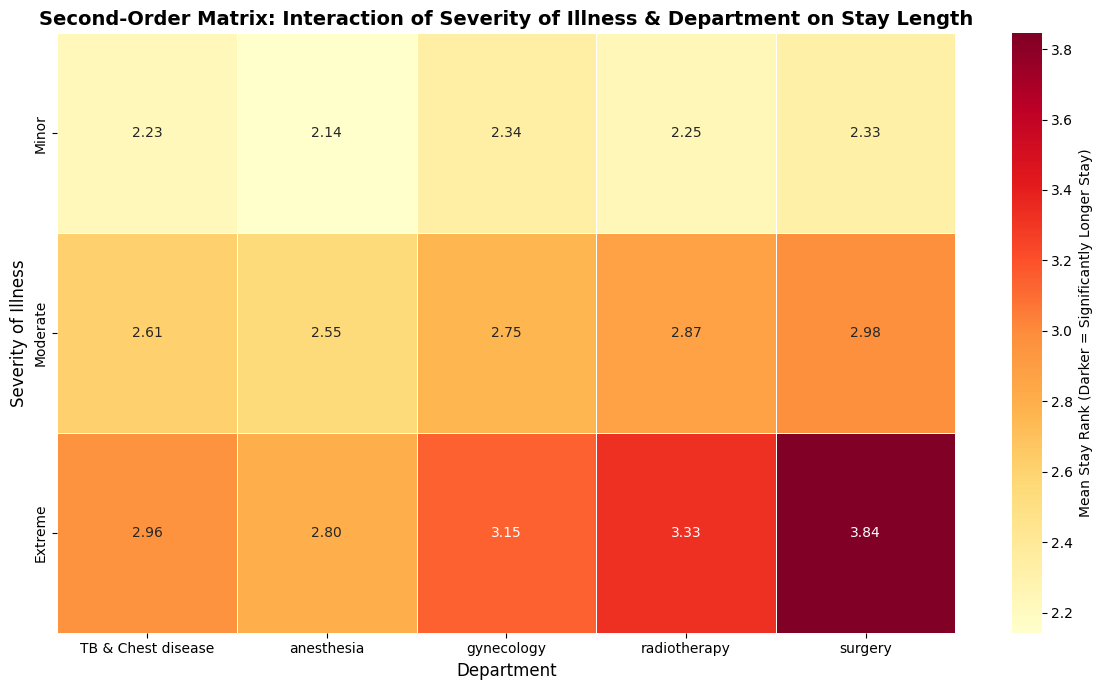

/tmp/ipykernel_27901/2362927074.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack()


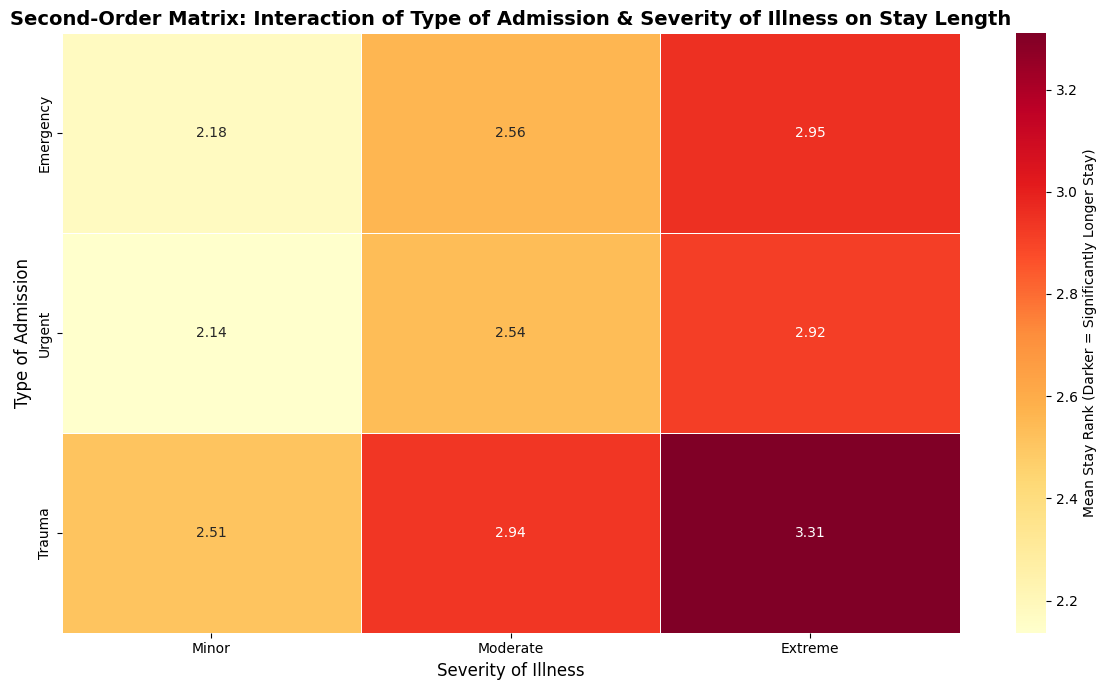

/tmp/ipykernel_27901/2362927074.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack()


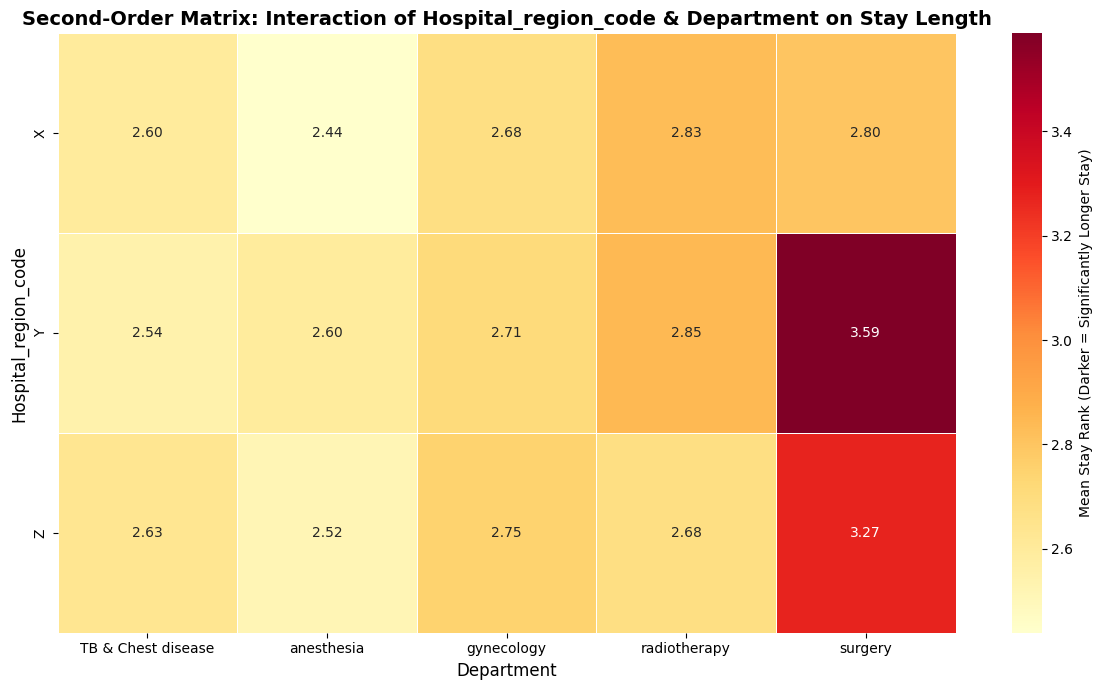

In [13]:
# ==============================================================================
# CELL 3: AUTOMATED SECOND-ORDER INTERACTION MATRICES
# ==============================================================================
def plot_second_order_correlation(dataframe, metric_a, metric_b):
    """
    Plots the structural intersection of two variables against numerical Stay ranks
    to detect hidden multi-variable patterns (e.g., Age compounding with Department).
    """
    # Map text stay categories to integers (0-10) to compute safe mathematical means [Certain]
    dataframe['Stay_Numeric_Rank'] = dataframe['Stay'].cat.codes

    # Calculate average stay tier for every cross-intersection
    pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack()

    plt.figure(figsize=(12, 7))
    sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5,
                cbar_kws={'label': 'Mean Stay Rank (Darker = Significantly Longer Stay)'})

    plt.title(f"Second-Order Matrix: Interaction of {metric_a} & {metric_b} on Stay Length", fontsize=14, fontweight='bold')
    plt.xlabel(metric_b, fontsize=12)
    plt.ylabel(metric_a, fontsize=12)
    plt.tight_layout()
    plt.show()

# Strategic cross-combinations to test complex operational scenarios
second_order_combinations = [
    ('Age', 'Department'),
    ('Age', 'Severity of Illness'),
    ('Severity of Illness', 'Department'),
    ('Type of Admission', 'Severity of Illness'),
    ('Hospital_region_code', 'Department')
]

# Run the second automation loop
for metric_a, metric_b in second_order_combinations:
    plot_second_order_correlation(df, metric_a, metric_b)

/tmp/ipykernel_27901/3890921109.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack()


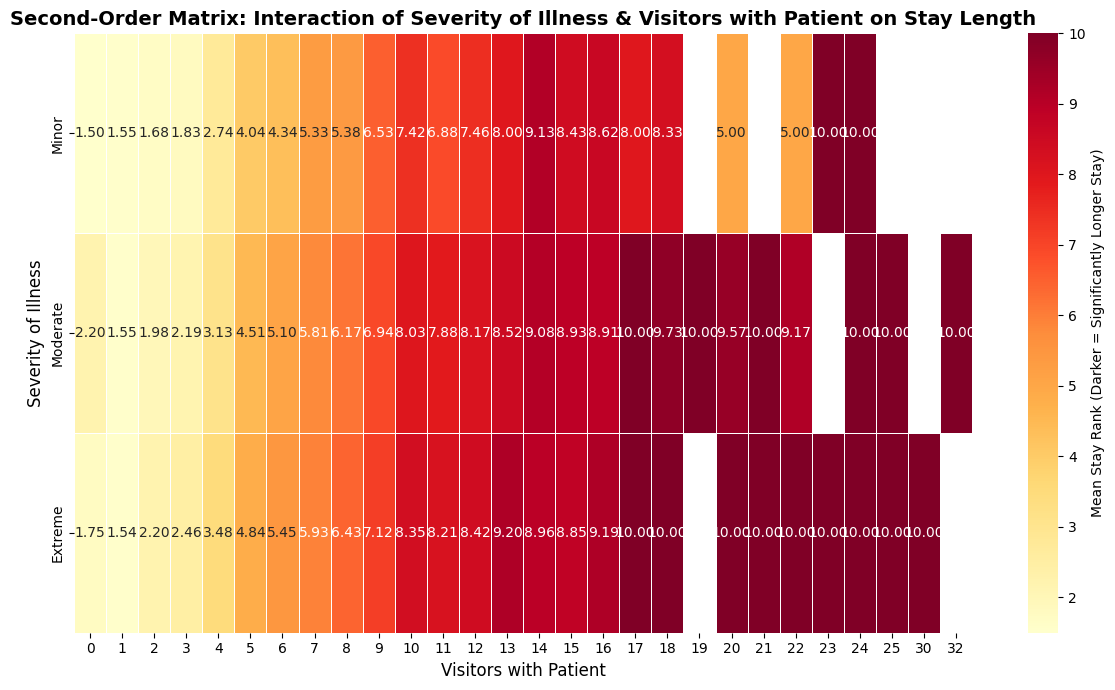

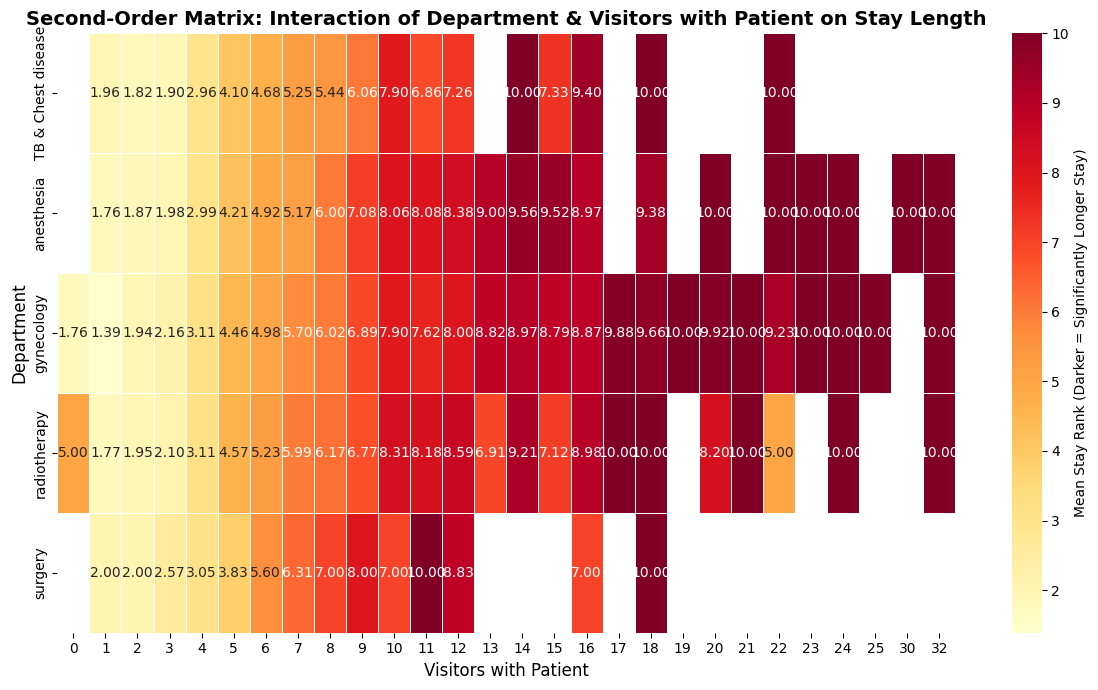

/tmp/ipykernel_27901/3890921109.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack()


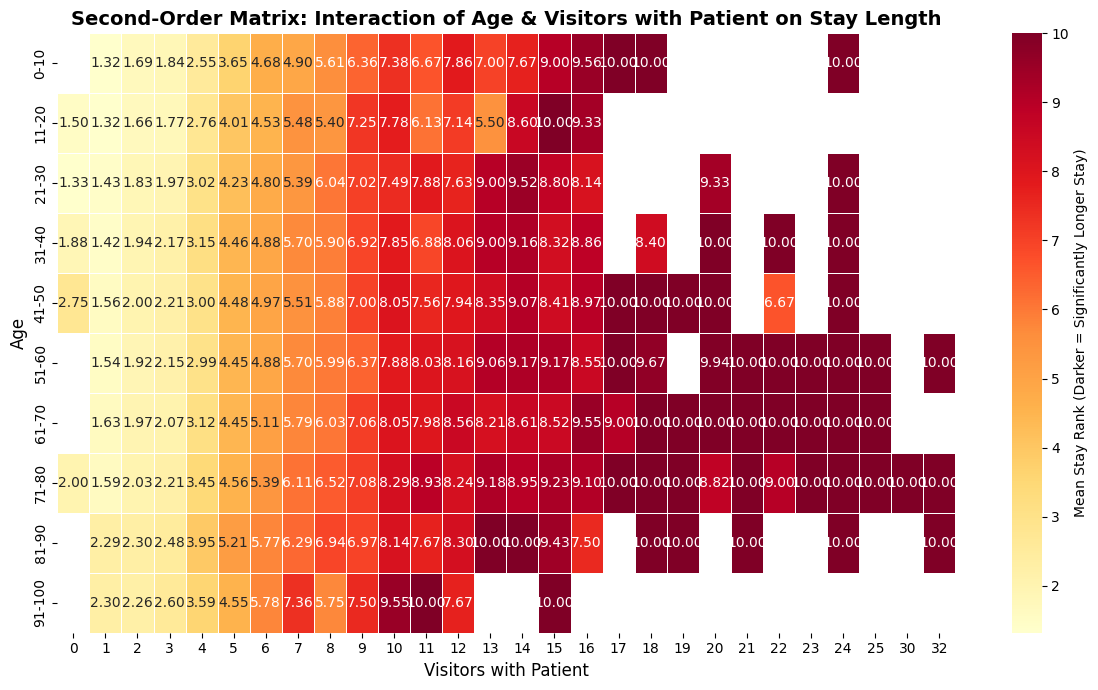

In [ ]:
# Updated combinations based on Seva's matrix findings
second_order_combinations = [
    ('Severity of Illness', 'Visitors with Patient'),
    ('Department', 'Visitors with Patient'),
    ('Age', 'Visitors with Patient')
]

# Run your loop to see the hidden patterns causing that 0.54 score!
for metric_a, metric_b in second_order_combinations:
    plot_second_order_correlation(df, metric_a, metric_b)

     SELECT A METRIC TO VISUALIZE FIRST-ORDER     
[0] Hospital_type_code
[1] Hospital_region_code
[2] Available Extra Rooms in Hospital
[3] Department
[4] Ward_Type
[5] Ward_Facility_Code
[6] Bed Grade
[7] Type of Admission
[8] Severity of Illness
[9] Visitors with Patient
[10] Age
[11] Admission_Deposit
Enter the NUMBER of the column you want to visualize: 11

🔄 Processing first-order distribution for: 'Admission_Deposit'...


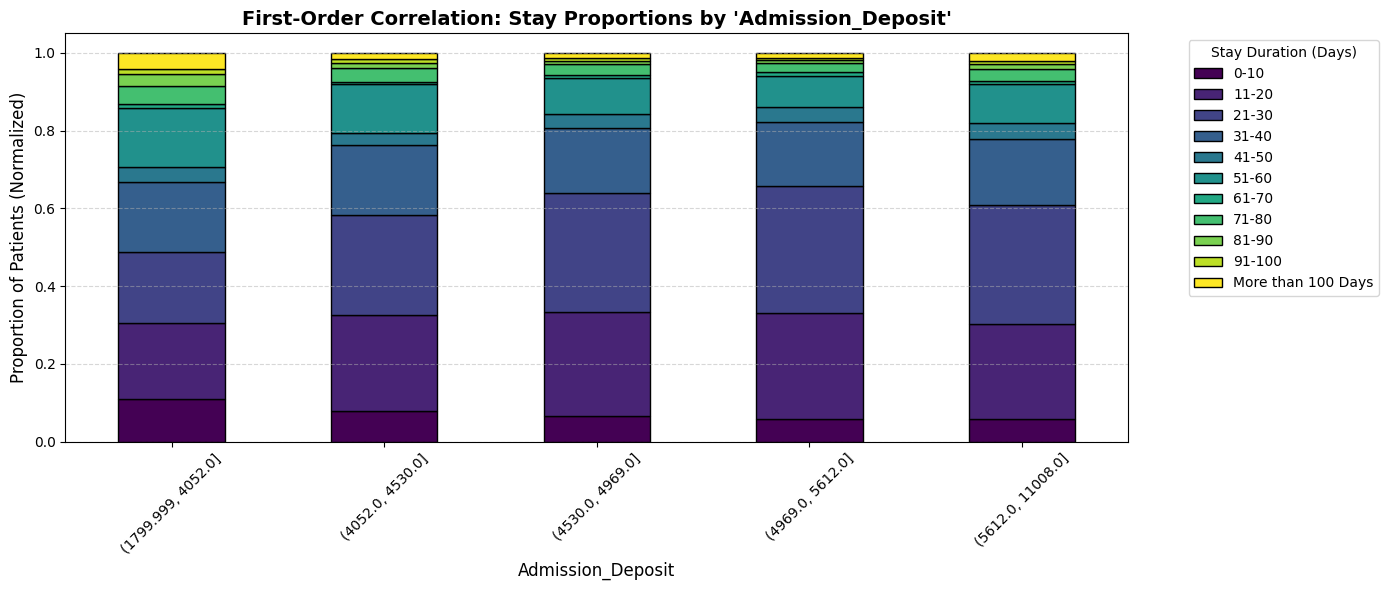

In [15]:
# ==============================================================================
# CELL 4 (UNIVERSAL): INTERACTIVE FIRST-ORDER VISUALIZATION CONTROLLER
# ==============================================================================

def universal_first_order_controller_v2(dataframe):
    """
    Universally compatible first-order controller that safely processes both
    categorical text and continuous numerical metrics by auto-binning numeric fields.
    """
    # Expanded list to match the 12 meaningful metrics of the second-order controller
    first_order_options = [
        'Hospital_type_code',
        'Hospital_region_code',
        'Available Extra Rooms in Hospital',
        'Department',
        'Ward_Type',
        'Ward_Facility_Code',
        'Bed Grade',
        'Type of Admission',
        'Severity of Illness',
        'Visitors with Patient',
        'Age',
        'Admission_Deposit'
    ]

    print("==================================================")
    print("     SELECT A METRIC TO VISUALIZE FIRST-ORDER     ")
    print("==================================================")
    for index, column in enumerate(first_order_options):
        print(f"[{index}] {column}")
    print("==================================================")

    try:
        user_choice = int(input("Enter the NUMBER of the column you want to visualize: "))
        if user_choice not in range(len(first_order_options)):
            print("❌ Invalid entry.")
            return
    except ValueError:
        print("❌ Error: Input must be a valid integer number.")
        return

    selected_column = first_order_options[user_choice]
    print(f"\n🔄 Processing first-order distribution for: '{selected_column}'...")

    # --- DEFENSIVE AUTOBINNING GUARD FOR CONTINUOUS VARIABLES ---
    # If the user selects a raw continuous number field, we temporarily bin it into chunks
    plot_data = dataframe.copy()

    if selected_column == 'Admission_Deposit':
        # Split deposit values into 5 clean numeric ranges
        plot_data['Admission_Deposit'] = pd.qcut(dataframe['Admission_Deposit'], q=5, duplicates='drop').astype(str)
    elif selected_column == 'Visitors with Patient':
        # Split visitor counts into ranges
        plot_data['Visitors with Patient'] = pd.cut(dataframe['Visitors with Patient'], bins=[-1, 2, 4, 6, 10, 100],
                                                    labels=['0-2 Visitors', '3-4 Visitors', '5-6 Visitors', '7-10 Visitors', '10+ Visitors']).astype(str)
    elif selected_column == 'Available Extra Rooms in Hospital':
        # Split extra rooms into distinct operational buckets
        plot_data['Available Extra Rooms in Hospital'] = pd.cut(dataframe['Available Extra Rooms in Hospital'], bins=[-1, 1, 3, 5, 25],
                                                                labels=['0-1 Rooms', '2-3 Rooms', '4-5 Rooms', '6+ Rooms']).astype(str)

    # --- RENDER ENGINE ---
    crosstab = pd.crosstab(plot_data[selected_column], plot_data['Stay'])
    crosstab_normalized = crosstab.div(crosstab.sum(1), axis=0)

    plt.figure(figsize=(14, 6))
    crosstab_normalized.plot(kind='bar', stacked=True, colormap='viridis', edgecolor='black', ax=plt.gca())

    plt.title(f"First-Order Correlation: Stay Proportions by '{selected_column}'", fontsize=14, fontweight='bold')
    plt.xlabel(selected_column, fontsize=12)
    plt.ylabel("Proportion of Patients (Normalized)", fontsize=12)
    plt.legend(title="Stay Duration (Days)", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

universal_first_order_controller_v2(df)

      HEALTHCARE DATA VISUALIZATION MENU          
[0] Hospital_type_code
[1] Hospital_region_code
[2] Available Extra Rooms in Hospital
[3] Department
[4] Ward_Type
[5] Ward_Facility_Code
[6] Bed Grade
[7] Type of Admission
[8] Severity of Illness
[9] Visitors with Patient
[10] Age
[11] Admission_Deposit
Enter the NUMBER for Variable A: 8
Enter the NUMBER for Variable B: 10

🔄 Extracting data and processing matrix for: Severity of Illness x Age...


/tmp/ipykernel_27901/764275097.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack()


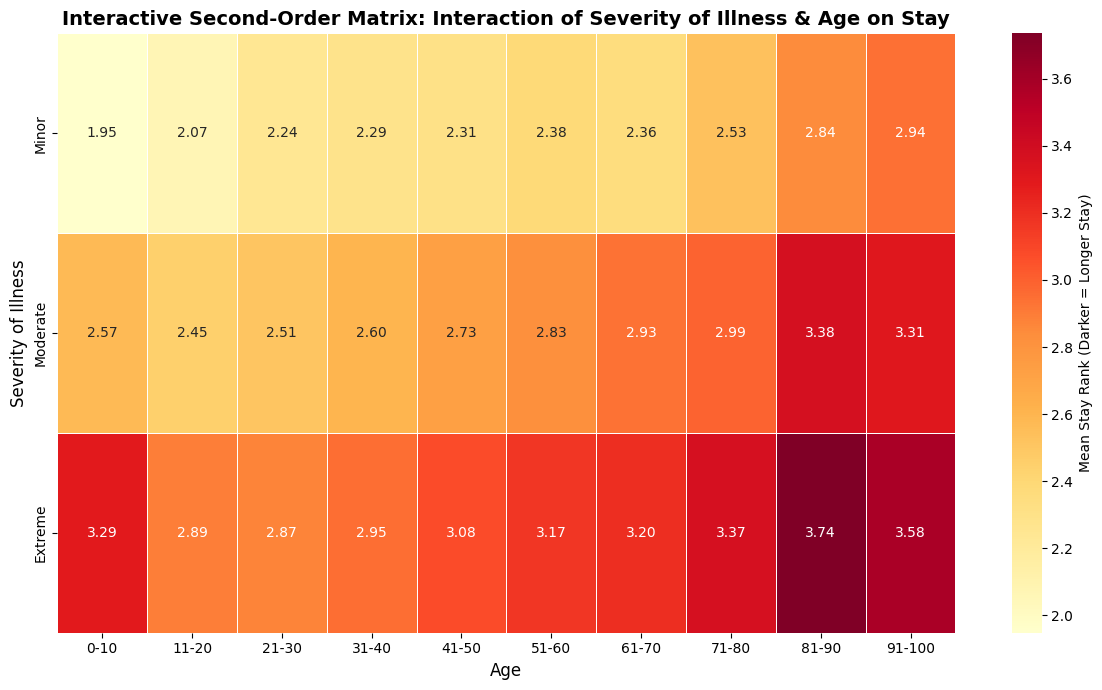

In [9]:
# ==============================================================================
# CELL 5: INTERACTIVE SECOND-ORDER VISUALIZATION CONTROLLER
# ==============================================================================

def interactive_correlation_controller(dataframe):
    """
    Launches an interactive menu in the Colab console allowing the user to select
    two variables by number and instantly rendering their second-order heatmap.
    """
    # Define the list of meaningful columns available for comparison
    available_metrics = [
        'Hospital_type_code',
        'Hospital_region_code',
        'Available Extra Rooms in Hospital',
        'Department',
        'Ward_Type',
        'Ward_Facility_Code',
        'Bed Grade',
        'Type of Admission',
        'Severity of Illness',
        'Visitors with Patient',
        'Age',
        'Admission_Deposit'
    ]

    # Ensure the numeric rank conversion column exists for the heatmap calculation [Certain]
    if 'Stay_Numeric_Rank' not in dataframe.columns:
        dataframe['Stay_Numeric_Rank'] = dataframe['Stay'].cat.codes

    # --- DISPLAY MENU TO USER ---
    print("==================================================")
    print("      HEALTHCARE DATA VISUALIZATION MENU          ")
    print("==================================================")
    for index, metric in enumerate(available_metrics):
        # Prints choices nicely formatted as: [0] Hospital_type_code
        print(f"[{index}] {metric}")
    print("==================================================")

    # --- GET SELECTION FOR VARIABLE A ---
    try:
        selection_a = int(input("Enter the NUMBER for Variable A: "))
        if selection_a not in range(len(available_metrics)):
            print("❌ Invalid selection. Please restart the cell and enter a valid number.")
            return
    except ValueError:
        print("❌ Error: You must enter an integer number.")
        return

    # --- GET SELECTION FOR VARIABLE B ---
    try:
        selection_b = int(input("Enter the NUMBER for Variable B: "))
        if selection_b not in range(len(available_metrics)):
            print("❌ Invalid selection. Please restart the cell and enter a valid number.")
            return
        if selection_a == selection_b:
            print("⚠️ Warning: Comparing a variable with itself will just show its direct trend.")
    except ValueError:
        print("❌ Error: You must enter an integer number.")
        return

    # Extract the exact string column names from our list using the chosen index markers
    metric_a = available_metrics[selection_a]
    metric_b = available_metrics[selection_b]

    # --- RENDER THE DESIRED PLOT ---
    print(f"\n🔄 Extracting data and processing matrix for: {metric_a} x {metric_b}...")

    # Generate the pivot grouping matrix
    pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack()

    # Build the heatmap plot architecture
    plt.figure(figsize=(12, 7))
    sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5,
                cbar_kws={'label': 'Mean Stay Rank (Darker = Longer Stay)'})

    plt.title(f"Interactive Second-Order Matrix: Interaction of {metric_a} & {metric_b} on Stay", fontsize=14, fontweight='bold')
    plt.xlabel(metric_b, fontsize=12)
    plt.ylabel(metric_a, fontsize=12)
    plt.tight_layout()
    plt.show()

# Run the controller function
interactive_correlation_controller(df)

   SELECT A CONTINUOUS METRIC FOR TREND ANALYSIS  
[0] Admission_Deposit
[1] Visitors with Patient
[2] Available Extra Rooms in Hospital
Enter NUMBER of the continuous metric to analyze: 0

🔄 Calculating median trends for: 'Admission_Deposit'...



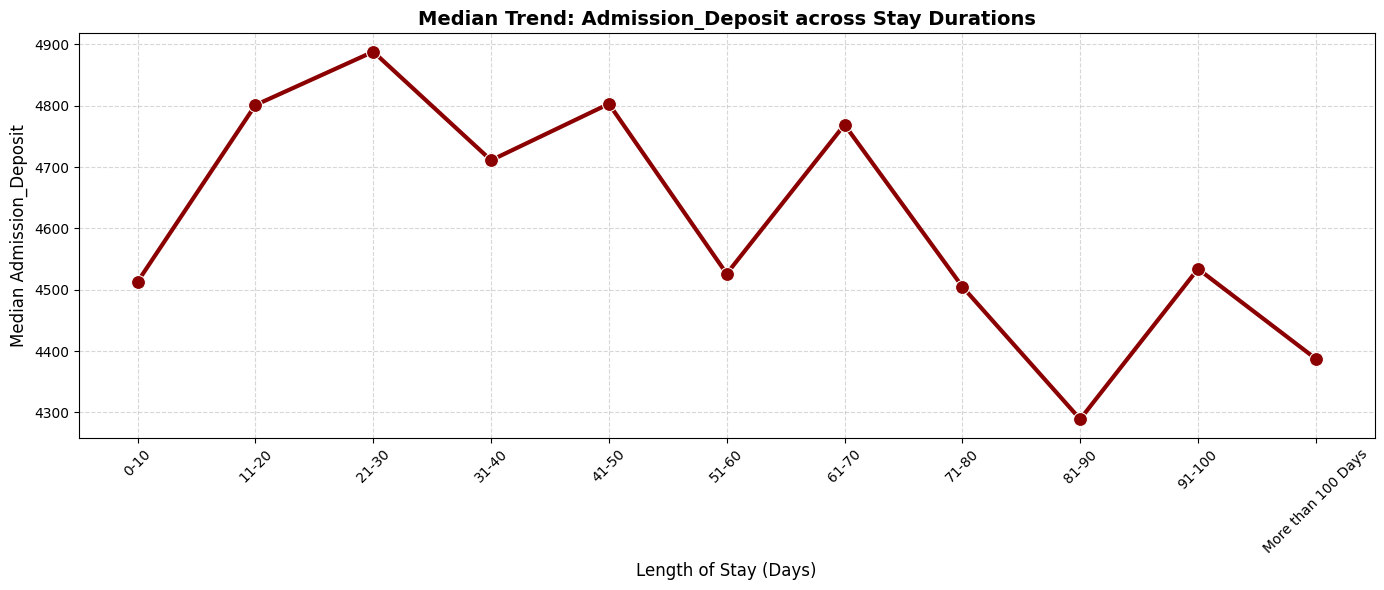

In [18]:
# ==============================================================================
# CELL 6: CONTINUOUS METRICS - MEDIAN TREND LINE CONTROLLER
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def median_trend_controller(dataframe):
    """
    Universally compatible controller to plot the median trend of continuous
    variables against the categorical Stay duration.
    """
    continuous_options = [
        'Admission_Deposit',
        'Visitors with Patient',
        'Available Extra Rooms in Hospital'
    ]

    print("==================================================")
    print("   SELECT A CONTINUOUS METRIC FOR TREND ANALYSIS  ")
    print("==================================================")
    for index, column in enumerate(continuous_options):
        print(f"[{index}] {column}")
    print("==================================================")

    try:
        user_choice = int(input("Enter NUMBER of the continuous metric to analyze: "))
        if user_choice not in range(len(continuous_options)):
            print("❌ Invalid entry.")
            return
    except ValueError:
        print("❌ Error: Input must be a valid integer number.")
        return

    selected_column = continuous_options[user_choice]
    print(f"\n🔄 Calculating median trends for: '{selected_column}'...\n")

    # --- RENDER THE MEDIAN TREND LINE ---
    plt.figure(figsize=(14, 6))

    # Seaborn's lineplot with estimator='median' automatically calculates
    # the exact center point for every single stay category and connects them.
    # We use the stay_order defined in Cell 1 to keep the X-axis chronological.
    sns.lineplot(x='Stay', y=selected_column, data=dataframe,
                 estimator='median', errorbar=None, marker='o',
                 linewidth=3, markersize=10, color='darkred')

    plt.title(f"Median Trend: {selected_column} across Stay Durations", fontsize=14, fontweight='bold')
    plt.xlabel("Length of Stay (Days)", fontsize=12)
    plt.ylabel(f"Median {selected_column}", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Run the controller
median_trend_controller(df)

The Cell above calculates the median admission deposit for each range of the length of stay column and assigns one value and then connects it to see if there is correlation. Basically, I made it because I was having trouble understanding the first order charts just by looking so I was thinking of other ways we could see it, but I dont think it works very well and we might have to discard it or improve it. So I made the cell block below which has its decrption under it.

[0] Hospital_type_code
[1] Hospital_region_code
[2] Department
[3] Ward_Type
[4] Ward_Facility_Code
[5] Type of Admission
[6] Severity of Illness
[7] Age
[8] Bed Grade
Enter NUMBER for the Metric you want to analyze: 4

[0] 0-10
[1] 11-20
[2] 21-30
[3] 31-40
[4] 41-50
[5] 51-60
[6] 61-70
[7] 71-80
[8] 81-90
[9] 91-100
[10] More than 100 Days
Enter NUMBER for the specific Stay Duration (Color) to isolate: 7

🔄 Isolating '71-80' within 'Ward_Facility_Code'...



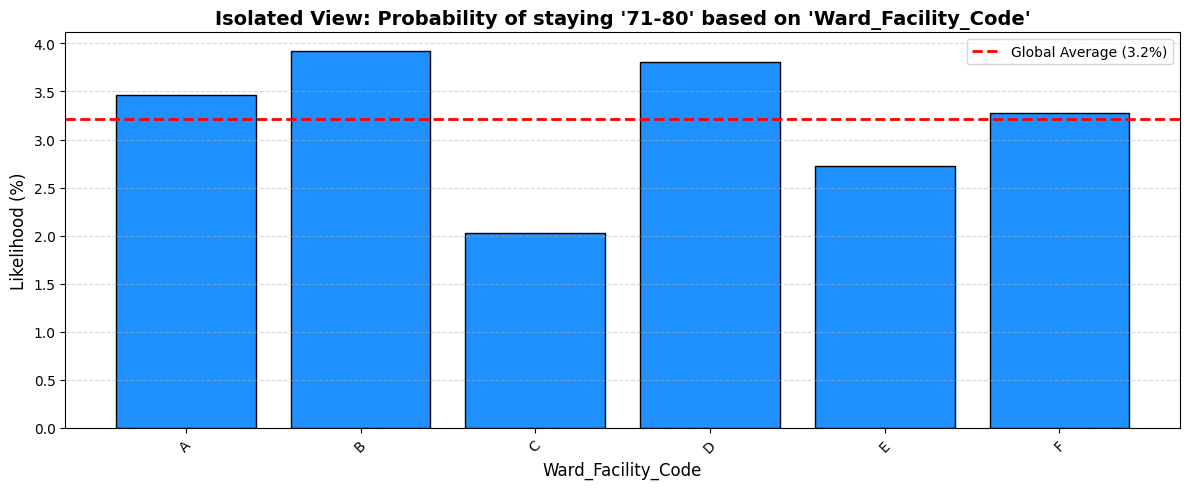


DETAILED STATISTICAL CONTEXT: '71-80' grouped by 'Ward_Facility_Code'
Baseline Global Probability: 3.22% of all patients stay this long.
                    Total Patients  Stayed 71-80 (Count)  Likelihood (%)  Shift from Baseline (%)
Ward_Facility_Code                                                                               
A                            27557                   953            3.46                     0.24
B                            34727                  1361            3.92                     0.70
C                            35144                   713            2.03                    -1.19
D                            51178                  1948            3.81                     0.59
E                            54181                  1479            2.73                    -0.49
F                           111006                  3642            3.28                     0.06



In [17]:
# ==============================================================================
# CELL 7: ISOLATED FIRST-ORDER DEEP DIVE (WITH DETAILED STATISTICS)
# ==============================================================================

def isolated_first_order_deep_dive(dataframe):
    """
    Allows the user to visually isolate a single stay category to eliminate
    baseline shifting, and generates a detailed statistical matrix for context.
    """
    categorical_options = [
        'Hospital_type_code', 'Hospital_region_code', 'Department',
        'Ward_Type', 'Ward_Facility_Code', 'Type of Admission',
        'Severity of Illness', 'Age', 'Bed Grade'
    ]

    # Step 1: Choose the independent variable
    print("==================================================")
    for index, column in enumerate(categorical_options):
        print(f"[{index}] {column}")
    print("==================================================")

    try:
        var_choice = int(input("Enter NUMBER for the Metric you want to analyze: "))
        selected_metric = categorical_options[var_choice]
    except:
        print("❌ Invalid entry.")
        return

    # Step 2: Choose the specific color/stay to isolate
    stay_categories = dataframe['Stay'].cat.categories.tolist()
    print("\n==================================================")
    for index, stay in enumerate(stay_categories):
        print(f"[{index}] {stay}")
    print("==================================================")

    try:
        stay_choice = int(input("Enter NUMBER for the specific Stay Duration (Color) to isolate: "))
        selected_stay = stay_categories[stay_choice]
    except:
        print("❌ Invalid entry.")
        return

    print(f"\n🔄 Isolating '{selected_stay}' within '{selected_metric}'...\n")

    # --- MATH & STATS CALCULATION ---
    # 1. Find the global average probability of this stay happening at all
    global_prob = (len(dataframe[dataframe['Stay'] == selected_stay]) / len(dataframe)) * 100

    # 2. Build the exact counts and percentage matrix for the selected metric [Certain]
    crosstab_counts = pd.crosstab(dataframe[selected_metric], dataframe['Stay'])
    crosstab_percentages = crosstab_counts.div(crosstab_counts.sum(1), axis=0) * 100

    # Extract just the column we care about
    isolated_percentages = crosstab_percentages[selected_stay]

    # --- RENDER ISOLATED VISUAL ---
    plt.figure(figsize=(12, 5))

    # Because it is only one variable, it sits flat on the X-axis. No visual shifting. [Certain]
    bars = plt.bar(isolated_percentages.index.astype(str), isolated_percentages.values, color='dodgerblue', edgecolor='black')

    # Draw a red line showing the baseline global average
    plt.axhline(global_prob, color='red', linestyle='--', linewidth=2, label=f'Global Average ({global_prob:.1f}%)')

    plt.title(f"Isolated View: Probability of staying '{selected_stay}' based on '{selected_metric}'", fontsize=14, fontweight='bold')
    plt.ylabel(f"Likelihood (%)", fontsize=12)
    plt.xlabel(selected_metric, fontsize=12)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # --- PRINT DETAILED NUMERICAL CONTEXT ---
    print("\n" + "="*70)
    print(f"DETAILED STATISTICAL CONTEXT: '{selected_stay}' grouped by '{selected_metric}'")
    print(f"Baseline Global Probability: {global_prob:.2f}% of all patients stay this long.")
    print("="*70)

    # Build a clean output table
    stats_df = pd.DataFrame({
        'Total Patients': crosstab_counts.sum(axis=1),
        f'Stayed {selected_stay} (Count)': crosstab_counts[selected_stay],
        'Likelihood (%)': isolated_percentages.round(2),
        'Shift from Baseline (%)': (isolated_percentages - global_prob).round(2)
    })

    print(stats_df.to_string())
    print("="*70 + "\n")

# Run the deep dive controller
isolated_first_order_deep_dive(df)

The cell block above is a kind of update or rather more specific version of the first order function. This allows us to break down the metric even further and search for specific ranges of length of stay. I might update it so its the other way around for example if we want to see just the war facility C against different ranges of length of stay. For now the above given code snippet also provides some mathematical context and numbers. I should integrate this into the main functions as well.